In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/home/leticia/filmes_imdb/desafio_indicium_imdb.csv', encoding='utf-8')

In [3]:
df.shape

(999, 16)

In [4]:
display(df)

,Unnamed: 0,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
1,2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
2,3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
3,4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
4,5,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,995,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN
995,996,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN
996,997,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,"30,500,000"
997,998,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN


## Limpeza e Tratamento dos Dados

In [5]:
#renomeando a coluna 'Unnamed' para id - Para facilitar a leitura.
df.rename(columns={'Unnamed: 0' : 'id'}, inplace=True)

In [6]:
#verificando se existem linhas duplicadas
df.duplicated().sum()

0

In [7]:
#verificando se existem valores nulos
df.isnull().values.any()

True

In [8]:
#quantidade de valores nulos
df.isnull().sum()

id                 0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [9]:
#preenchendo os valores Nan da coluna certificate com o valor 'unknow'
df['Certificate'].fillna('Unknown', inplace=True)

In [10]:
#preenchendo os valores NaN da coluna meta_score com a mediana dos valoes
meta_score = df['Meta_score'].median()
df['Meta_score'].fillna(meta_score, inplace=True)

In [11]:
# removendo as vírgulas e convertendo a coluna de faturamento para o tipo float
df['Gross'] = df['Gross'].str.replace(',', '').astype(float)

In [12]:
#preenchendo os valores NaN da coluna de faturamento com a mediana dos valores.
faturamento = df['Gross'].median()
df['Gross'].fillna(faturamento, inplace=True)

In [13]:
#verificando se existem linhas com caracteres especiais nos titulos
caracteres_especiais = df[df['Series_Title'].str.contains(r'[^\x00-\x7F]+', regex=True)]
print(caracteres_especiais)

      id                                       Series_Title Released_Year  \
25    26                                    La vita è bella          1997   
41    42                                               Léon          1994   
52    53                                         Capharnaüm          2018   
65    66                                             WALL·E          2008   
94    95                                             Amélie          2001   
114  115                         Per qualche dollaro in più          1965   
124  125                  M - Eine Stadt sucht einen Mörder          1931   
174  175                                        Höstsonaten          1978   
180  181                                            Yôjinbô          1961   
183  184                                    Smultronstället          1957   
187  188                                   Tôkyô monogatari          1953   
188  189                                           Rashômon          1950   

In [14]:
#verificando se tem linhas com caracteres especiais na coluna overview
caracteres_especiais_over = df[df['Overview'].str.contains(r'[^\x00-\x7F]+', regex=True)]
print(caracteres_especiais_over)

      id                     Series_Title Released_Year Certificate  Runtime  \
41    42                             Léon          1994           A  110 min   
53    54        Ayla: The Daughter of War          2017     Unknown  125 min   
94    95                           Amélie          2001           U  122 min   
189  190                    All About Eve          1950      Passed  138 min   
269  270         Kaze no tani no Naushika          1984           U  117 min   
275  276                 The Elephant Man          1980          UA  124 min   
365  366                         G.O.R.A.          2004     Unknown  127 min   
472  473                   Thor: Ragnarok          2017          UA  130 min   
648  649                      The Insider          1999          UA  157 min   
700  701     Guess Who's Coming to Dinner          1967     Unknown  108 min   
733  734                   La vie d'Adèle          2013           A  180 min   
742  743                Midnight in Pari

In [15]:
#verificando se o tipo dos dados esta correto em todas as colunas
df.dtypes

id                 int64
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross            float64
dtype: object

In [16]:
#Verificando os valores unicos da coluna Released_Year
#Indentifiquei um valor não numerico que precisa ser tratado
released_year_unico = df['Released_Year'].unique()
print(released_year_unico)

['1972' '2008' '1974' '1957' '2003' '1994' '1993' '2010' '1999' '2001'
 '1966' '2002' '1990' '1980' '1975' '2020' '2019' '2014' '1998' '1997'
 '1995' '1991' '1977' '1962' '1954' '1946' '2011' '2006' '2000' '1988'
 '1985' '1968' '1960' '1942' '1936' '1931' '2018' '2017' '2016' '2012'
 '2009' '2007' '1984' '1981' '1979' '1971' '1963' '1964' '1950' '1940'
 '2013' '2005' '2004' '1992' '1987' '1986' '1983' '1976' '1973' '1965'
 '1959' '1958' '1952' '1948' '1944' '1941' '1927' '1921' '2015' '1996'
 '1989' '1978' '1961' '1955' '1953' '1925' '1924' '1982' '1967' '1951'
 '1949' '1939' '1937' '1934' '1928' '1926' '1920' '1970' '1969' '1956'
 '1947' '1945' '1930' '1938' '1935' '1933' '1932' '1922' '1943' 'PG']


In [17]:
# Removendo os valores não numéricos na coluna Released_Year
df = df[pd.to_numeric(df['Released_Year'], errors='coerce').notnull()]

# convertendo a coluna Released_Year para int
df['Released_Year'] = df['Released_Year'].astype(int)

In [18]:
# Removendo a string "min" e convertendo a coluna Runtime para int
df['Runtime'] = df['Runtime'].str.replace(' min', '').astype(int)

In [19]:
# Convertendo a coluna No_of_Votes para int
df['No_of_Votes'] = df['No_of_Votes'].astype(int)

In [20]:
# Verificando os tipos dos dados para garantir que as conversões estão corretas
print(df.dtypes)

id                 int64
Series_Title      object
Released_Year      int64
Certificate       object
Runtime            int64
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross            float64
dtype: object


In [21]:
#Padronizando os textos e removendo espaços extras
colunas = ['Series_Title', 'Certificate', 'Genre', 'Overview', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']

for col in colunas:
    df[col] = df[col].str.strip().str.title()

In [22]:
# Criando a coluna Main_Genre para mostrar apenas a categoria principal dos filmes
df['Main_Genre'] = df['Genre'].apply(lambda x: x.split(',')[0] if pd.notnull(x) else 'Unknown')

# Verificando a nova coluna
df[['Genre', 'Main_Genre']].head()

,Genre,Main_Genre
0,"Crime, Drama",Crime
1,"Action, Crime, Drama",Action
2,"Crime, Drama",Crime
3,"Crime, Drama",Crime
4,"Action, Adventure, Drama",Action


In [23]:
# Verificando consistência de valores categóricos
print(df['Certificate'].value_counts())
print(df['Main_Genre'].value_counts())

Certificate
U           233
A           196
Ua          175
R           146
Unknown     101
Pg-13        43
Pg           37
Passed       34
G            12
Approved     11
Tv-Pg         3
Gp            2
Tv-14         1
16            1
Tv-Ma         1
Unrated       1
U/A           1
Name: count, dtype: int64
Main_Genre
Drama        288
Action       172
Comedy       155
Crime        107
Biography     88
Animation     82
Adventure     71
Mystery       12
Horror        11
Western        4
Film-Noir      3
Fantasy        2
Family         2
Thriller       1
Name: count, dtype: int64


# Análise Exploratória
Vamos responder algumas perguntas e identificar insights sobre tendências e padrões nos dados.

In [24]:
filme = df[['id', 'Series_Title', 'Main_Genre', 'IMDB_Rating', 'Gross']].groupby(['id']).sum()
filme = filme.sort_values(by='IMDB_Rating', ascending=False)
display(filme)

,Series_Title,Main_Genre,IMDB_Rating,Gross
id,,,,
1,The Godfather,Crime,9.2,134966411.0
3,The Godfather: Part Ii,Crime,9.0,57300000.0
4,12 Angry Men,Crime,9.0,4360000.0
2,The Dark Knight,Action,9.0,534858444.0
5,The Lord Of The Rings: The Return Of The King,Action,8.9,377845905.0
...,...,...,...,...
912,Zombieland,Adventure,7.6,75590286.0
911,La Piel Que Habito,Drama,7.6,3185812.0
910,Moneyball,Biography,7.6,75605492.0


In [25]:
#em que ano foram lançados mais filmes?
ano = df['Released_Year'].value_counts().idxmax()
qtde_filmes = df['Released_Year'].value_counts().max()
print(f"Em {ano} foram lançados a maior quantidade de filmes, com um total de {qtde_filmes} filmes.")

Em 2014 foram lançados a maior quantidade de filmes, com um total de 32 filmes.


In [26]:
#em que ano foram lançados os filmes com maior nota?

filmes_maior_nota = df.nlargest(5, 'IMDB_Rating')

# Mostra os títulos dos filmes, as notas e o ano de lançamento
print("Os TOP 5 filmes com a maior nota são:")
print(filmes_maior_nota[['Series_Title', 'Released_Year', 'IMDB_Rating']])

Os TOP 5 filmes com a maior nota são:
                                    Series_Title  Released_Year  IMDB_Rating
0                                  The Godfather           1972          9.2
1                                The Dark Knight           2008          9.0
2                         The Godfather: Part Ii           1974          9.0
3                                   12 Angry Men           1957          9.0
4  The Lord Of The Rings: The Return Of The King           2003          8.9


Os 5 gêneros de filme que mais foram lançados nas últimas duas décadas são:
Main_Genre
Drama        133
Action       106
Comedy        59
Biography     51
Animation     51
Name: count, dtype: int64


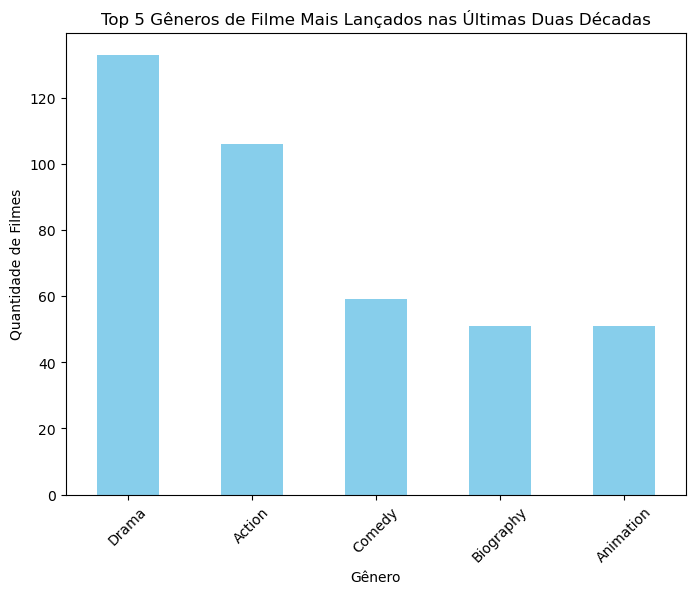

In [27]:
# qual gênero de filme mais foi lançado nas últimas duas décadas - top 5

decadas = df[df['Released_Year'] >= (df['Released_Year'].max() - 20)]
top5_generos = decadas['Main_Genre'].value_counts().nlargest(5)

print("Os 5 gêneros de filme que mais foram lançados nas últimas duas décadas são:")
print(top5_generos)


plt.figure(figsize=(8, 6))
top5_generos.plot(kind='bar', color='skyblue')
plt.title('Top 5 Gêneros de Filme Mais Lançados nas Últimas Duas Décadas')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Filmes')
plt.xticks(rotation=45)
plt.show()

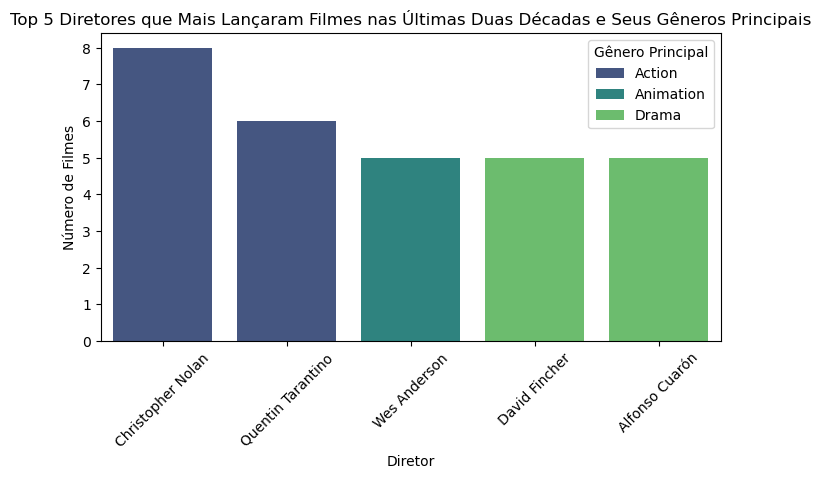

In [28]:
#Quais diretores mais lançaram filmes nas últimas duas décadas - top 5

decadas = df[df['Released_Year'] >= (df['Released_Year'].max() - 20)]

top5_diretores = decadas['Director'].value_counts().nlargest(5)

# criando um dataframe com os diretores e seus filmes
diretores_filmes = decadas[decadas['Director'].isin(top5_diretores.index)]

# determinando o gênero principal de cada diretor
genero_diretor = diretores_filmes.groupby('Director')['Main_Genre'].agg(lambda x: x.value_counts().idxmax())

# criando um dataframe final para plotar o grafico
df_plot = top5_diretores.reset_index()
df_plot.columns = ['Director', 'Film_Count']
df_plot['Main_Genre'] = df_plot['Director'].map(genero_diretor)

# criando o gráfico de barras
plt.figure(figsize=(8, 4))
sns.barplot(x='Director', y='Film_Count', hue='Main_Genre', data=df_plot, dodge=False, palette='viridis')
plt.title('Top 5 Diretores que Mais Lançaram Filmes nas Últimas Duas Décadas e Seus Gêneros Principais')
plt.xlabel('Diretor')
plt.ylabel('Número de Filmes')
plt.xticks(rotation=45)
plt.legend(title='Gênero Principal')
plt.show()

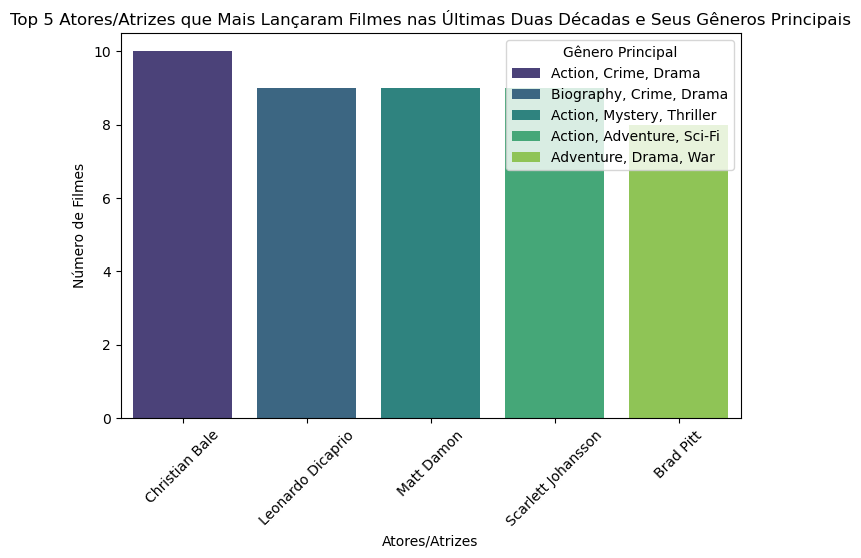

In [29]:
#Quais atores/atrizes mais lançaram filmes nas últimas duas décadas - top 5
decadas = df[df['Released_Year'] >= (df['Released_Year'].max() - 20)]

top5_atores = decadas[['Star1', 'Star2', 'Star3', 'Star4']].stack().value_counts().nlargest(5)

atores_filmes = decadas[decadas[['Star1', 'Star2', 'Star3', 'Star4']].apply(lambda x: any(actor in top5_atores.index for actor in x), axis=1)]

genero_ator = atores_filmes.melt(id_vars=['Genre'], value_vars=['Star1', 'Star2', 'Star3', 'Star4'], 
                                 var_name='Star_Role', value_name='Actor')
genero_ator = genero_ator[genero_ator['Actor'].isin(top5_atores.index)]
genero_ator_contagem = genero_ator.groupby('Actor')['Genre'].agg(lambda x: x.value_counts().idxmax())

df_plot = top5_atores.reset_index()
df_plot.columns = ['Actor', 'Film_Count']
df_plot['Main_Genre'] = df_plot['Actor'].map(genero_ator_contagem)

plt.figure(figsize=(8, 5))
sns.barplot(x='Actor', y='Film_Count', hue='Main_Genre', data=df_plot, dodge=False, palette='viridis')
plt.title('Top 5 Atores/Atrizes que Mais Lançaram Filmes nas Últimas Duas Décadas e Seus Gêneros Principais')
plt.xlabel('Atores/Atrizes')
plt.ylabel('Número de Filmes')
plt.xticks(rotation=45)
plt.legend(title='Gênero Principal')
plt.show()

O ano em que as pessoas mais votaram foi 2014.
O filme mais votado foi 'The Dark Knight' com 2303232 votos.
Os 5 filmes mais votados são:
       Series_Title  No_of_Votes Main_Genre
1   The Dark Knight      2303232     Action
7         Inception      2067042     Action
8        Fight Club      1854740      Drama
5      Pulp Fiction      1826188      Crime
10     Forrest Gump      1809221      Drama


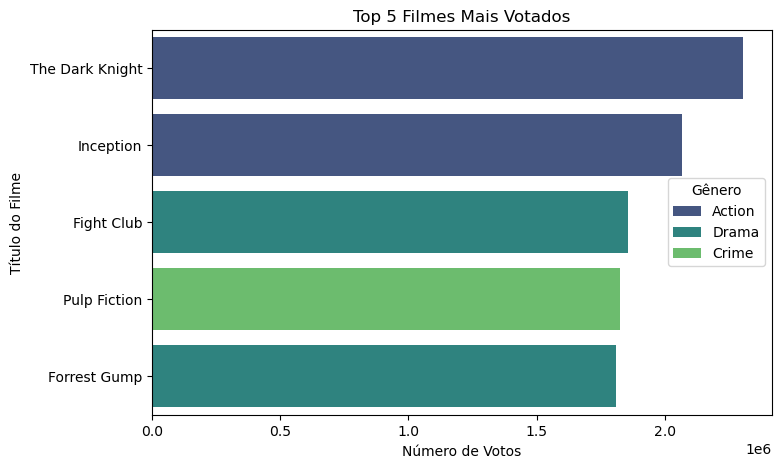

In [30]:
#Em qual ano as pessoas mais votaram e qual filme e gênero mais votados - top 5

ano_mais_votos = df.groupby('Released_Year')['No_of_Votes'].sum().idxmax()

filme_mais_votado = df.loc[df['No_of_Votes'].idxmax()]
top_5_filmes_mais_votados = df.nlargest(5, 'No_of_Votes')[['Series_Title', 'No_of_Votes', 'Main_Genre']]

print(f"O ano em que as pessoas mais votaram foi {ano_mais_votos}.")
print(f"O filme mais votado foi '{filme_mais_votado['Series_Title']}' com {filme_mais_votado['No_of_Votes']} votos.")
print("Os 5 filmes mais votados são:")
print(top_5_filmes_mais_votados)


plt.figure(figsize=(8, 5))
sns.barplot(x='No_of_Votes', y='Series_Title', hue='Main_Genre', data=top_5_filmes_mais_votados, dodge=False, palette='viridis')
plt.title('Top 5 Filmes Mais Votados')
plt.xlabel('Número de Votos')
plt.ylabel('Título do Filme')
plt.legend(title='Gênero')
plt.show()

In [31]:
#Em que ano foi lançado o filme mais longo e quantos minutos ele tem?

filme_mais_longo = df.loc[df['Runtime'].idxmax()]
print(f"O filme mais longo é '{filme_mais_longo['Series_Title']}', foi lançado em {filme_mais_longo['Released_Year']} e tem {filme_mais_longo['Runtime']} minutos.")

O filme mais longo é 'Gangs Of Wasseypur', foi lançado em 2012 e tem 321 minutos.


In [32]:
#Qual década teve maior faturamento?

df['Decada'] = (df['Released_Year'] // 10) * 10
maior_faturamento_decada = df.groupby('Decada')['Gross'].sum().idxmax()
total_faturamento_decada = df.groupby('Decada')['Gross'].sum().max()
print(f"A década com maior faturamento foi a de {maior_faturamento_decada}, com um faturamento total de {total_faturamento_decada}.")

filmes_decada = df[df['Decada'] == maior_faturamento_decada]
filme_maior_faturamento_decada = filmes_decada.loc[filmes_decada['Gross'].idxmax()]

print(f"O filme com maior faturamento na década de {maior_faturamento_decada} foi '{filme_maior_faturamento_decada['Series_Title']}' com um faturamento de {filme_maior_faturamento_decada['Gross']}.")

A década com maior faturamento foi a de 2010, com um faturamento total de 22933228537.5.
O filme com maior faturamento na década de 2010 foi 'Star Wars: Episode Vii - The Force Awakens' com um faturamento de 936662225.0.


In [33]:
# Qual ano teve o maior numero de lançamentos?

ano_mais_lancamentos = df['Released_Year'].value_counts().idxmax()
total_lancamentos = df['Released_Year'].value_counts().max()
print(f"O ano com maior número de lançamentos foi {ano_mais_lancamentos}, com um total de {total_lancamentos} lançamentos.")


filmes_ano = df[df['Released_Year'] == ano_mais_lancamentos]

#Qual filme teve o maior faturamento no ano?
filme_maior_faturamento_ano = filmes_ano.loc[filmes_ano['Gross'].idxmax()]

print(f"O filme com maior faturamento no ano de {ano_mais_lancamentos} foi '{filme_maior_faturamento_ano['Series_Title']}' com um faturamento de {filme_maior_faturamento_ano['Gross']}.")

O ano com maior número de lançamentos foi 2014, com um total de 32 lançamentos.
O filme com maior faturamento no ano de 2014 foi 'Guardians Of The Galaxy' com um faturamento de 333176600.0.


A categoria de filme mais lançada ao longo dos anos é: Drama

Numero de lançamentos por categoria:
Main_Genre
Drama        288
Action       172
Comedy       155
Crime        107
Biography     88
Animation     82
Adventure     71
Mystery       12
Horror        11
Western        4
Film-Noir      3
Fantasy        2
Family         2
Thriller       1
Name: count, dtype: int64


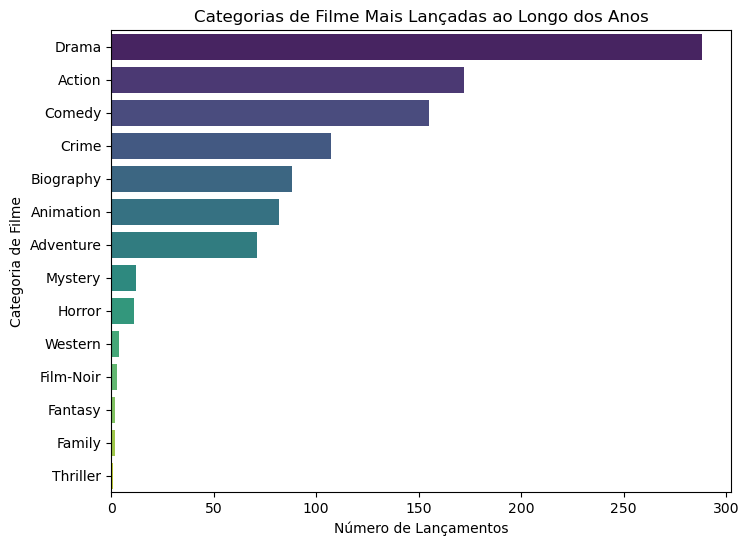

In [34]:
#qual foi a categoria de filme mais lançada ao longo dos anos

categoria_mais_lancada = df['Main_Genre'].value_counts().idxmax()
contagem_generos = df['Main_Genre'].value_counts()

print(f"A categoria de filme mais lançada ao longo dos anos é: {categoria_mais_lancada}")
print("\nNumero de lançamentos por categoria:")
print(contagem_generos)

plt.figure(figsize=(8, 6))
sns.barplot(x=contagem_generos.values, y=contagem_generos.index, palette='viridis')
plt.title('Categorias de Filme Mais Lançadas ao Longo dos Anos')
plt.xlabel('Número de Lançamentos')
plt.ylabel('Categoria de Filme')
plt.show()

A correlação entre tempo de duração e faturamento é: 0.13805695838605248


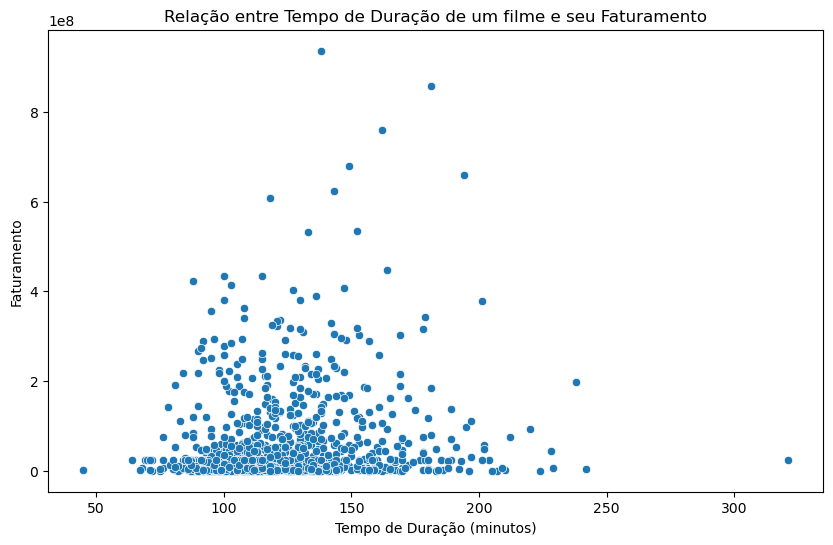

In [35]:
#o Tempo de duração de um filme tem a ver com seu faturamento?

correlacao_duracao_faturamento = df['Runtime'].corr(df['Gross'])
print(f"A correlação entre tempo de duração e faturamento é: {correlacao_duracao_faturamento}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Runtime', y='Gross', data=df)
plt.title('Relação entre Tempo de Duração de um filme e seu Faturamento')
plt.xlabel('Tempo de Duração (minutos)')
plt.ylabel('Faturamento')
plt.show()

In [36]:
#Tempo de duração x gênero

duracao_genero = df.groupby('Main_Genre')['Runtime'].mean().sort_values(ascending=False)
print("Duração média por gênero:")
print(duracao_genero)

Duração média por gênero:
Main_Genre
Western      148.250000
Biography    136.022727
Adventure    134.028169
Action       129.046512
Crime        126.392523
Drama        124.677083
Mystery      119.083333
Comedy       112.129032
Thriller     108.000000
Family       107.500000
Film-Noir    104.000000
Horror       102.090909
Animation     99.585366
Fantasy       85.000000
Name: Runtime, dtype: float64


Os 5 diretores que dirigem os filmes mais longos são:
Director
Kenneth Branagh       242.0
Anurag Kashyap        232.5
Cecil B. Demille      220.0
Ashutosh Gowariker    217.0
Ramesh Sippy          204.0
Name: Runtime, dtype: float64


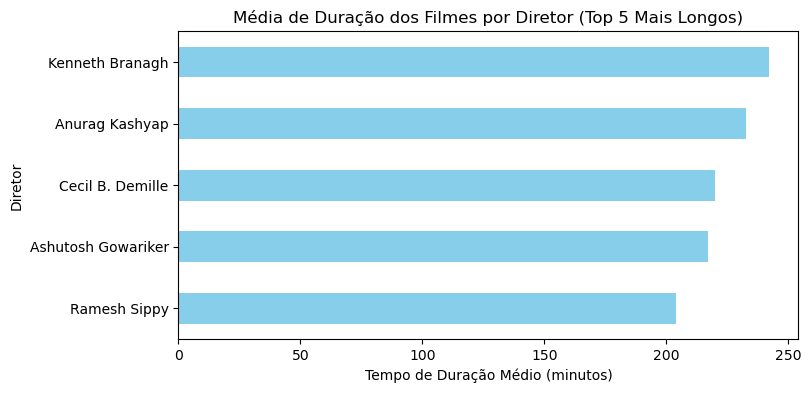

In [37]:
#Tempo de duração x diretor - qual diretor dirige filmes mais longos - top 5

duracao_diretor = df.groupby('Director')['Runtime'].mean().nlargest(5)
print("Os 5 diretores que dirigem os filmes mais longos são:")
print(duracao_diretor)

duracao_diretor = df.groupby('Director')['Runtime'].mean().nlargest(5)


plt.figure(figsize=(8, 4))
duracao_diretor.plot(kind='barh', color='skyblue')
plt.title('Média de Duração dos Filmes por Diretor (Top 5 Mais Longos)')
plt.xlabel('Tempo de Duração Médio (minutos)')
plt.ylabel('Diretor')
plt.gca().invert_yaxis()
plt.show()

In [38]:
#Quais são os atores/atrizes mais frequentes nos filmes do conjunto de dados? Top 5

top_star = df[['Star1', 'Star2', 'Star3', 'Star4']].stack().value_counts().nlargest(5)

print("Atores/Atrizes mais frequentes nos filmes são:")
print(top_star)

Atores/Atrizes mais frequentes nos filmes são:
Robert De Niro    17
Tom Hanks         13
Al Pacino         13
Clint Eastwood    12
Brad Pitt         12
Name: count, dtype: int64


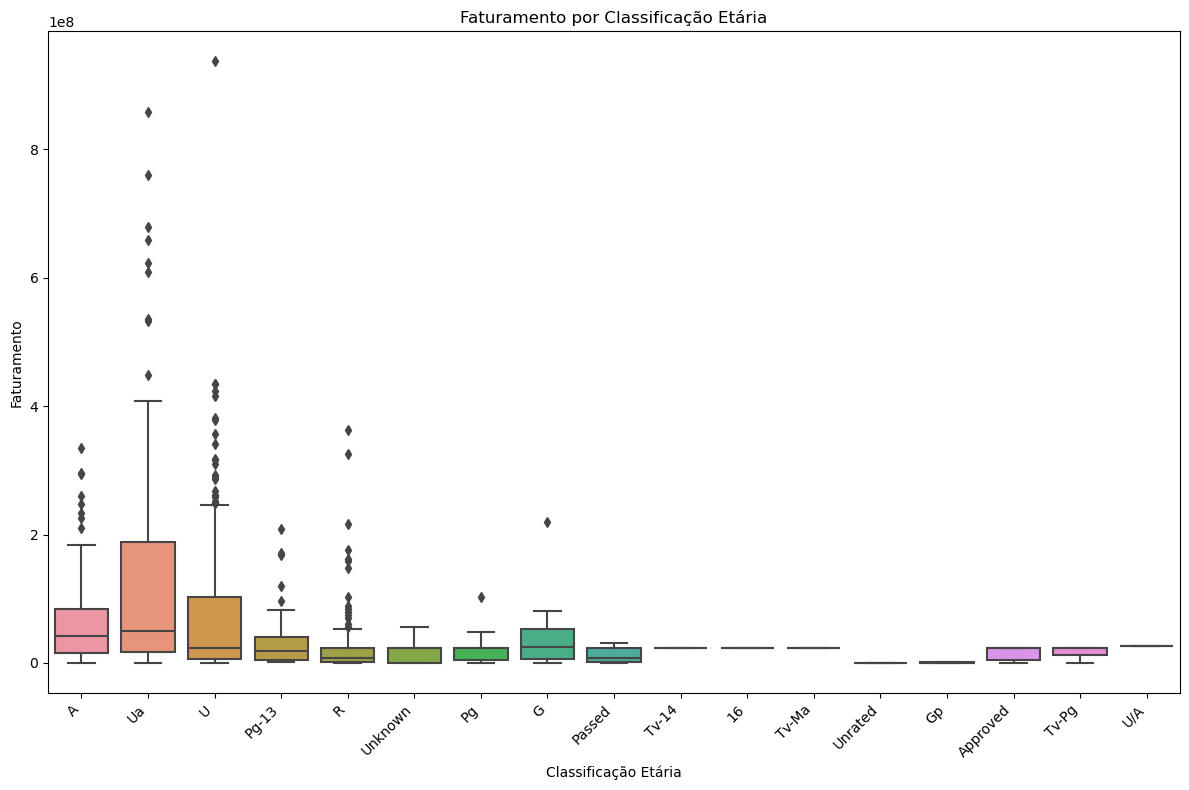

In [39]:
#Classificação Etária x Faturamento

plt.figure(figsize=(12, 8))
sns.boxplot(x='Certificate', y='Gross', data=df)
plt.title('Faturamento por Classificação Etária')
plt.xlabel('Classificação Etária')
plt.ylabel('Faturamento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

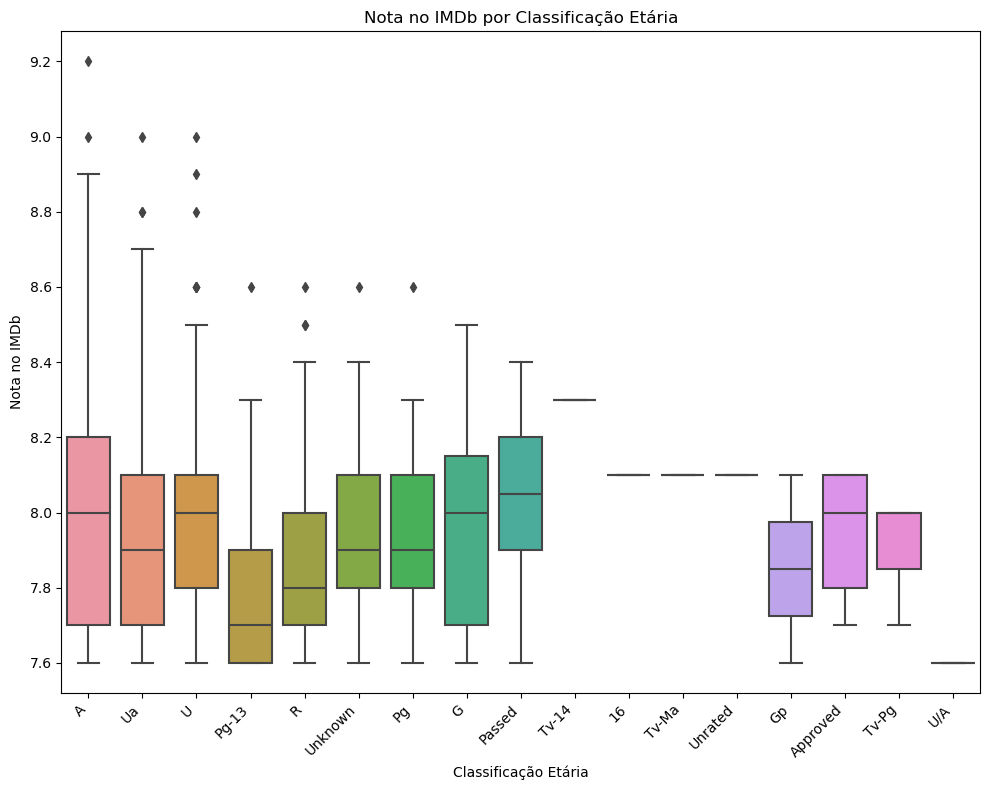

In [40]:
# Classificação Etária x Nota no IMDb


plt.figure(figsize=(10, 8))
sns.boxplot(x='Certificate', y='IMDB_Rating', data=df)
plt.title('Nota no IMDb por Classificação Etária')
plt.xlabel('Classificação Etária')
plt.ylabel('Nota no IMDb')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

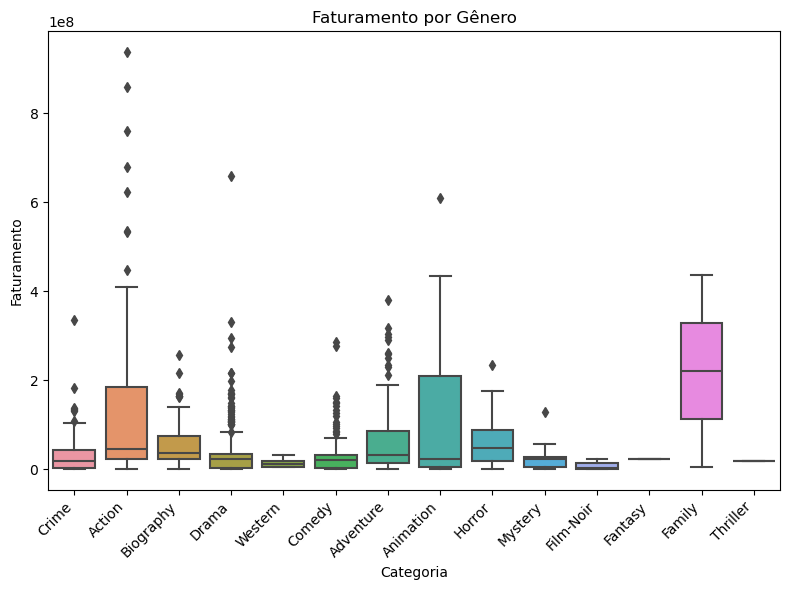

In [41]:
# Faturamento x Gênero Principal

plt.figure(figsize=(8, 6))
sns.boxplot(x='Main_Genre', y='Gross', data=df)
plt.title('Faturamento por Gênero')
plt.xlabel('Categoria')
plt.ylabel('Faturamento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

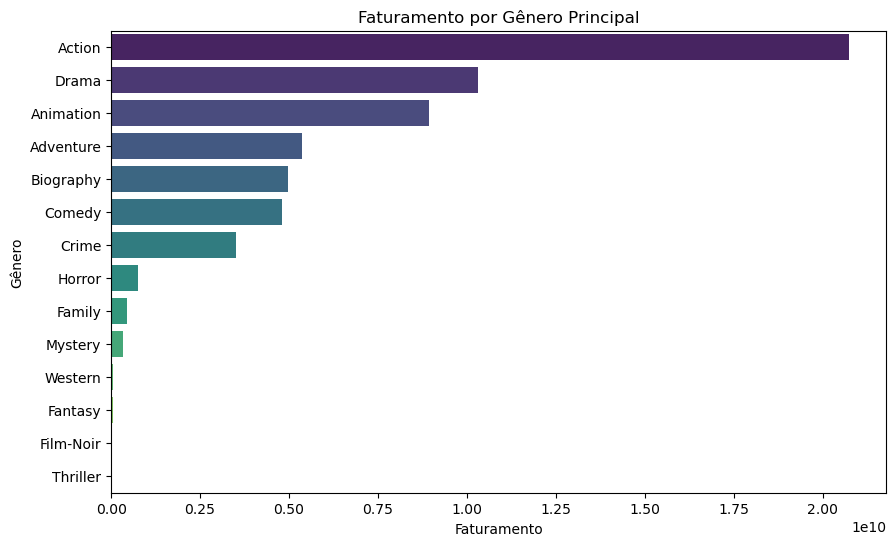

In [42]:
# Qual categoria tem o faturamento mais alto?

faturamento_por_genero = df.groupby('Main_Genre')['Gross'].sum().reset_index()

faturamento_por_genero = faturamento_por_genero.sort_values(by='Gross', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Gross', y='Main_Genre', data=faturamento_por_genero, palette='viridis')
plt.title('Faturamento por Gênero Principal')
plt.xlabel('Faturamento')
plt.ylabel('Gênero')
plt.show()

/home/leticia/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/leticia/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


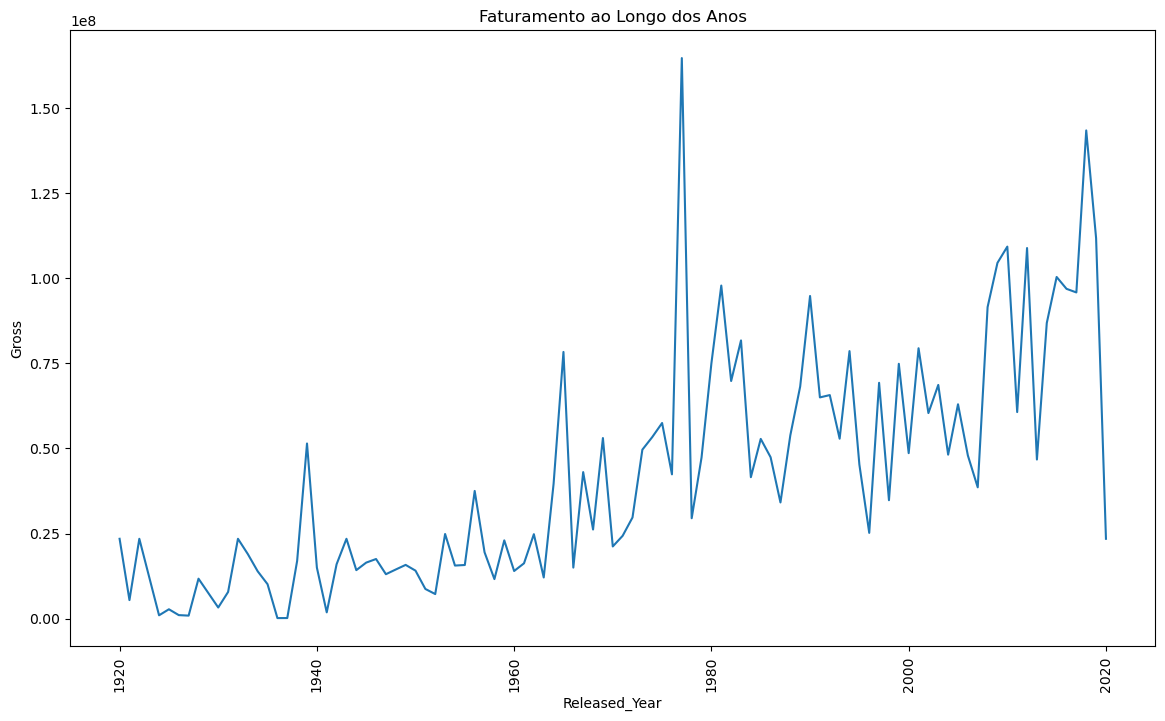

In [43]:
#Faturamento ao Longo dos Anos
plt.figure(figsize=(14, 8))
sns.lineplot(data=df, x='Released_Year', y='Gross', errorbar=None)
plt.xticks(rotation=90)
plt.title('Faturamento ao Longo dos Anos')
plt.show();

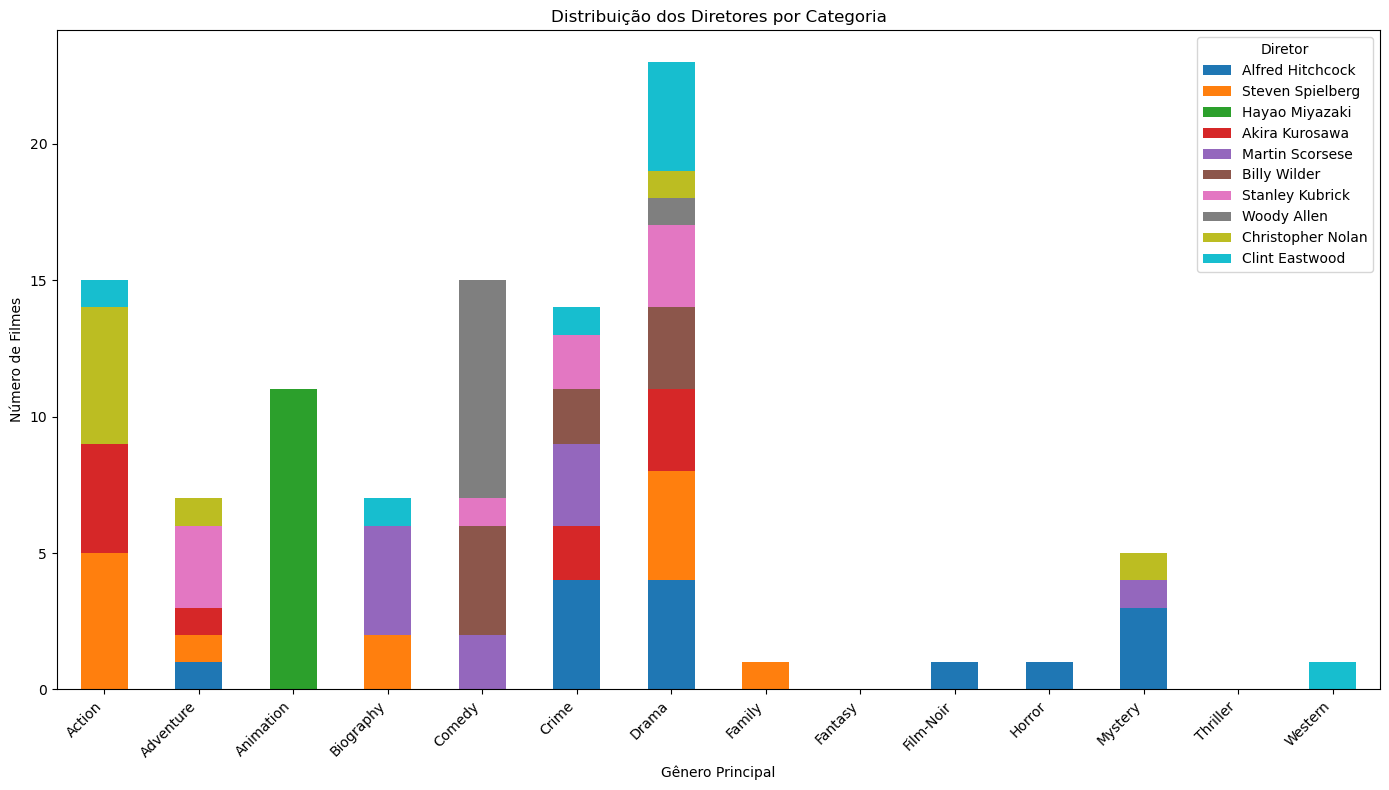

In [44]:
# Diretores x gênero principal
director_genre = df.groupby(['Main_Genre', 'Director']).size().unstack().fillna(0)

top_directors = director_genre.sum().nlargest(10).index

director_genre[top_directors].plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Distribuição dos Diretores por Categoria')
plt.xlabel('Gênero Principal')
plt.ylabel('Número de Filmes')
plt.legend(title='Diretor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

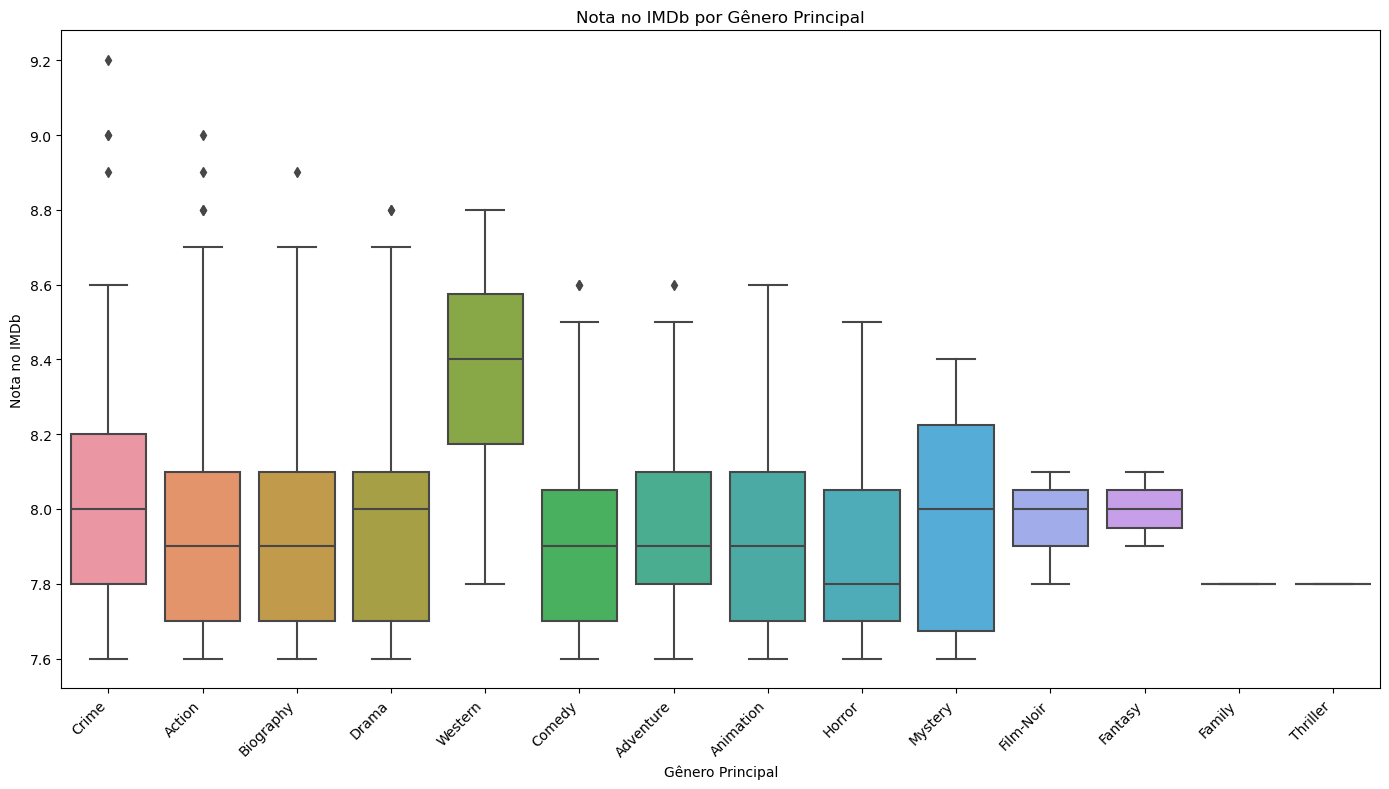

In [45]:
# Nota no IMDb x Categoria

plt.figure(figsize=(14, 8))
sns.boxplot(x='Main_Genre', y='IMDB_Rating', data=df)
plt.title('Nota no IMDb por Gênero Principal')
plt.xlabel('Gênero Principal')
plt.ylabel('Nota no IMDb')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

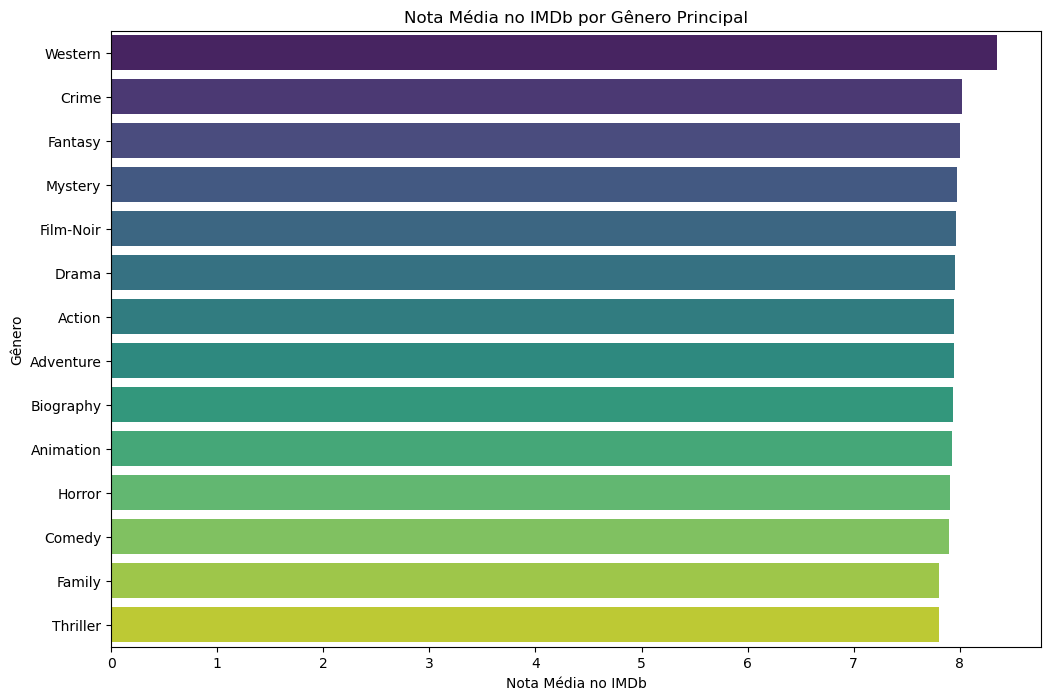

In [46]:
# Qual a média de notas do IMDB por categoria de filme?

nota_imdb_genero = df.groupby('Main_Genre')['IMDB_Rating'].mean().reset_index()
nota_imdb_genero = nota_imdb_genero.sort_values(by='IMDB_Rating', ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(x='IMDB_Rating', y='Main_Genre', data=nota_imdb_genero, palette='viridis')
plt.title('Nota Média no IMDb por Gênero Principal')
plt.xlabel('Nota Média no IMDb')
plt.ylabel('Gênero')
plt.show()

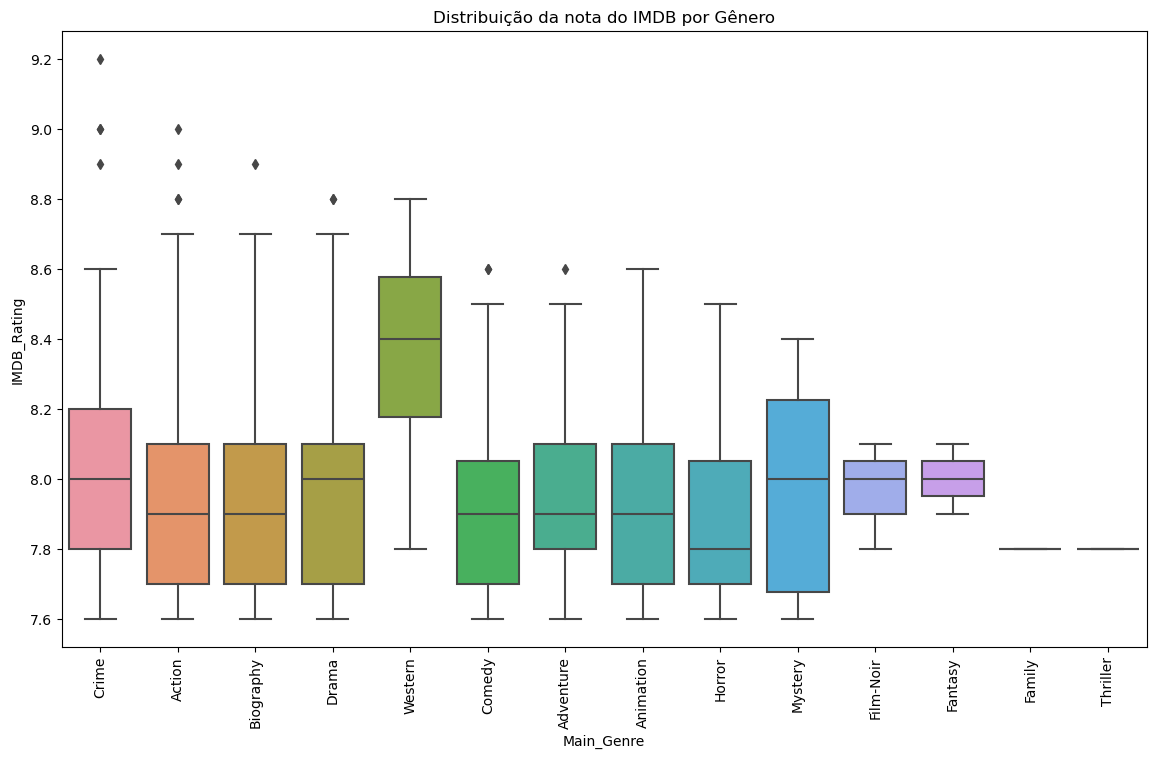

In [47]:
#Como é a distribuição de IMDB_Rating por Gênero
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='Main_Genre', y='IMDB_Rating')
plt.xticks(rotation=90)
plt.title('Distribuição da nota do IMDB por Gênero')
plt.show()

## Recomendação de Filme

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import NearestNeighbors

In [49]:
df.head()

,id,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Main_Genre,Decada
0,1,The Godfather,1972,A,175,"Crime, Drama",9.2,An Organized Crime Dynasty'S Aging Patriarch T...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,Crime,1970
1,2,The Dark Knight,2008,Ua,152,"Action, Crime, Drama",9.0,When The Menace Known As The Joker Wreaks Havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,Action,2000
2,3,The Godfather: Part Ii,1974,A,202,"Crime, Drama",9.0,The Early Life And Career Of Vito Corleone In ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,Crime,1970
3,4,12 Angry Men,1957,U,96,"Crime, Drama",9.0,A Jury Holdout Attempts To Prevent A Miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,Crime,1950
4,5,The Lord Of The Rings: The Return Of The King,2003,U,201,"Action, Adventure, Drama",8.9,Gandalf And Aragorn Lead The World Of Men Agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian Mckellen,Orlando Bloom,1642758,377845905.0,Action,2000


In [50]:
# selecionando os atributos numericos
colunas_numericas = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']
X = df[colunas_numericas].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(X_scaled)

def recomendar(filme_nome):
    indice_filme = df[df['Series_Title'] == filme_nome].index[0]
    distancia, indices = knn.kneighbors([X_scaled[indice_filme]])
    recomendados = df.iloc[indices[0][1:]][['Series_Title','Released_Year','IMDB_Rating']]
    return recomendados

# Exemplo de uso
print(recomendar("Pulp Fiction"))

                 Series_Title  Released_Year  IMDB_Rating
27   The Silence Of The Lambs           1991          8.6
36               The Departed           2006          8.5
105                    Aliens           1986          8.3
0               The Godfather           1972          9.2
97            American Beauty           1999          8.3


# Fatores Relacionados com a alta expectativa de faturamento de um filme

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [52]:
# transformando log em Gross para reduzir a dispersão
df['Gross_log'] = np.log1p(df['Gross'])

In [53]:
# aelecionando as features numéricas
var_num = ['Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Released_Year']
X = df[var_num]
y = df['Gross_log']

In [54]:
# dividindo as variaveis em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
# treinado o modelo Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_treino, y_treino)

RandomForestRegressor(n_estimators=200, random_state=42)

In [56]:
# avaliando a acuracia do modelo
y_previsao = rf.predict(X_teste)
print("R²:", r2_score(y_teste, y_previsao))
print("RMSE:", np.sqrt(mean_squared_error(y_teste, y_previsao)))

R²: 0.32744524626028637
RMSE: 1.6449339521470152


In [57]:
# relevancia das features
importancia = pd.Series(rf.feature_importances_, index=var_num).sort_values(ascending=False)
print(importancia)

No_of_Votes      0.477454
Released_Year    0.197929
Runtime          0.121546
Meta_score       0.119031
IMDB_Rating      0.084040
dtype: float64


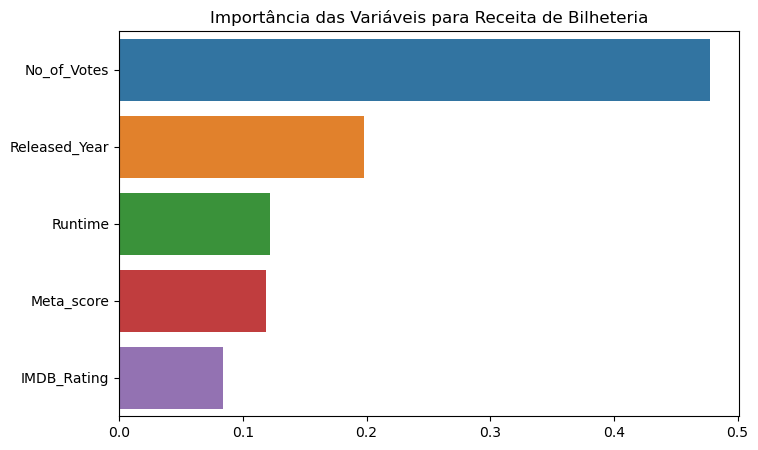

In [58]:
# Visualização
plt.figure(figsize=(8,5))
sns.barplot(x=importancia, y=importancia.index)
plt.title("Importância das Variáveis para Receita de Bilheteria")
plt.show()

## Quais insights podem ser tirados com a coluna Overview? É possível inferir o gênero do filme a partir dessa coluna?

In [59]:
import spacy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score

In [60]:
nlp = spacy.load('en_core_web_sm')

In [61]:
def preproces_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    return ' '.join(tokens)

In [62]:
df['Proces_Overview'] = df['Overview'].apply(preproces_text)

In [63]:
X_overview = df['Proces_Overview']
y_overview = df['Main_Genre']

In [64]:
X_treino_overview, X_teste_overview, y_treino_overview, y_teste_overview = train_test_split(X_overview, y_overview, test_size=0.2, random_state=42)

In [65]:
modelo = make_pipeline(TfidfVectorizer(), MultinomialNB())

# treinando o modelo
modelo.fit(X_treino_overview, y_treino_overview)

Pipeline(steps=[('tfidfvectorizer', TfidfVectorizer()),
                ('multinomialnb', MultinomialNB())])

In [66]:
previsao_overview = modelo.predict(X_teste_overview)

print("Accuracy:", accuracy_score(y_teste_overview, previsao_overview))
print(classification_report(y_teste_overview, previsao_overview))

Accuracy: 0.345
              precision    recall  f1-score   support

      Action       0.55      0.19      0.29        31
   Adventure       0.00      0.00      0.00        16
   Animation       0.00      0.00      0.00        20
   Biography       0.00      0.00      0.00        18
      Comedy       0.00      0.00      0.00        28
       Crime       0.00      0.00      0.00        21
       Drama       0.33      0.98      0.50        64
      Family       0.00      0.00      0.00         1
      Horror       0.00      0.00      0.00         1

    accuracy                           0.34       200
   macro avg       0.10      0.13      0.09       200
weighted avg       0.19      0.34      0.20       200



/home/leticia/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/leticia/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/leticia/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [67]:
from sklearn.decomposition import LatentDirichletAllocation

# vetorizando o texto
vetorizar = TfidfVectorizer()
X_tfidf = vetorizar.fit_transform(df['Proces_Overview'])

# aplicando lda para descobrir os tópicos
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_tfidf)

# mostrando os tópicos
for i, topic in enumerate(lda.components_):
    print(f"Top 10 palavras do Tópico #{i}:")
    print([vetorizar.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print("\n")

Top 10 palavras do Tópico #0:
['woman', 'love', 'new', 'world', 'story', 'family', 'life', 'young', 'find', 'man']


Top 10 palavras do Tópico #1:
['old', 'year', 'woman', 'family', 'war', 'boy', 'find', 'life', 'young', 'man']


Top 10 palavras do Tópico #2:
['come', 'young', 'girl', 'son', 'year', 'mother', 'father', 'try', 'find', 'life']


Top 10 palavras do Tópico #3:
['turn', 'woman', 'father', 'world', 'find', 'family', 'friend', 'man', 'life', 'young']


Top 10 palavras do Tópico #4:
['lead', 'wife', 'human', 'new', 'love', 'woman', 'world', 'war', 'young', 'life']




In [68]:
overview_novo = "Descrição do novo filme"
processed_overview = preproces_text(overview_novo)

previsao_genero = modelo.predict([processed_overview])
print("Gênero previsto:", previsao_genero)

Gênero previsto: ['Drama']


## Supondo um filme com as seguintes características:
 
{'Series_Title': 'The Shawshank Redemption',
 'Released_Year': '1994',
 'Certificate': 'A',
 'Runtime': '142 min',
 'Genre': 'Drama',
 'Overview': 'Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.',
 'Meta_score': 80.0,
 'Director': 'Frank Darabont',
 'Star1': 'Tim Robbins',
 'Star2': 'Morgan Freeman',
 'Star3': 'Bob Gunton',
 'Star4': 'William Sadler',
 'No_of_Votes': 2343110,
 'Gross': '28,341,469'}
 
 
Qual seria a nota do IMDB?


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer

In [70]:
data = pd.read_csv('/home/leticia/filmes_imdb/desafio_indicium_imdb.csv', encoding='utf-8')

In [71]:
data.rename(columns={'Unnamed: 0': 'id'}, inplace=True)

In [72]:
data['Certificate'].fillna('Unknown', inplace=True)
meta_score = data['Meta_score'].median()
data['Meta_score'].fillna(meta_score, inplace=True)
data['Gross'] = data['Gross'].str.replace(',', '')
data['Gross'] = data['Gross'].astype(float)
faturamento = data['Gross'].median()
data['Gross'].fillna(faturamento, inplace=True)
data = data[pd.to_numeric(data['Released_Year'], errors='coerce').notnull()]
data['Released_Year'] = data['Released_Year'].astype(int)
data['Runtime'] = data['Runtime'].str.replace(' min', '').astype(int)
data['No_of_Votes'] = data['No_of_Votes'].astype(int)

In [73]:
# caracteristicas do novo filme
novo_filme = {
    'Series_Title': 'The Shawshank Redemption',
    'Released_Year': 1994,
    'Certificate': 'A',
    'Runtime': 142,
    'Genre': 'Drama',
    'Meta_score': 80.0,
    'Director': 'Frank Darabont',
    'Star1': 'Tim Robbins',
    'Star2': 'Morgan Freeman',
    'Star3': 'Bob Gunton',
    'Star4': 'William Sadler',
    'No_of_Votes': 2343110,
    'Gross': 28341469
}

In [74]:
novo_filme_df = pd.DataFrame([novo_filme])
data_novo = pd.concat([data, novo_filme_df], ignore_index=True)

# Codificação de variáveis categóricas
colunas_categ = ['Certificate', 'Genre', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']
label_encoders = {}

for col in colunas_categ:
    label_encoders[col] = LabelEncoder()
    data_novo[col] = label_encoders[col].fit_transform(data_novo[col])

In [75]:
data = data_novo.iloc[:-1]
novo_filme_encoded = data_novo.iloc[-1]

X = data.drop(['IMDB_Rating', 'Series_Title', 'Overview'], axis=1)
y = data['IMDB_Rating']

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [76]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
# Definindo os modelos
modelos = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'LinearRegression': LinearRegression()
}

# Treinando e avaliando os modelos
results = {}
for nome_modelo, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    previsao = modelo.predict(X_teste)
    mse = mean_squared_error(y_teste, previsao)
    results[nome_modelo] = mse

# Mostrando os resultados
for nome_modelo, mse in results.items():
    print(f'{nome_modelo}: MSE = {mse:.2f}')

RandomForest: MSE = 0.00
GradientBoosting: MSE = 0.00
LinearRegression: MSE = 0.00


In [78]:
novo_filme_encoded = novo_filme_encoded[X.columns]
novo_filme_df = pd.DataFrame([novo_filme_encoded])
novo_filme_df = pd.DataFrame(imputer.transform(novo_filme_df), columns=novo_filme_df.columns)

In [79]:
melhor_modelo_nome = min(results, key=results.get)
melhor_modelo = modelos[melhor_modelo_nome]
previsao_rating = melhor_modelo.predict(novo_filme_df)

print(f'Predicted IMDb Rating for The Shawshank Redemption: {previsao_rating[0]:.2f}')

Predicted IMDb Rating for The Shawshank Redemption: 7.90


## Salvar as bases pre processadas

In [80]:
import pickle

In [81]:
with open('imdb.pkl', mode='wb') as f:
    pickle.dump([X_treino, y, X_teste, y_teste], f)